ValueError: Invalid RGBA argument: 'emerald'

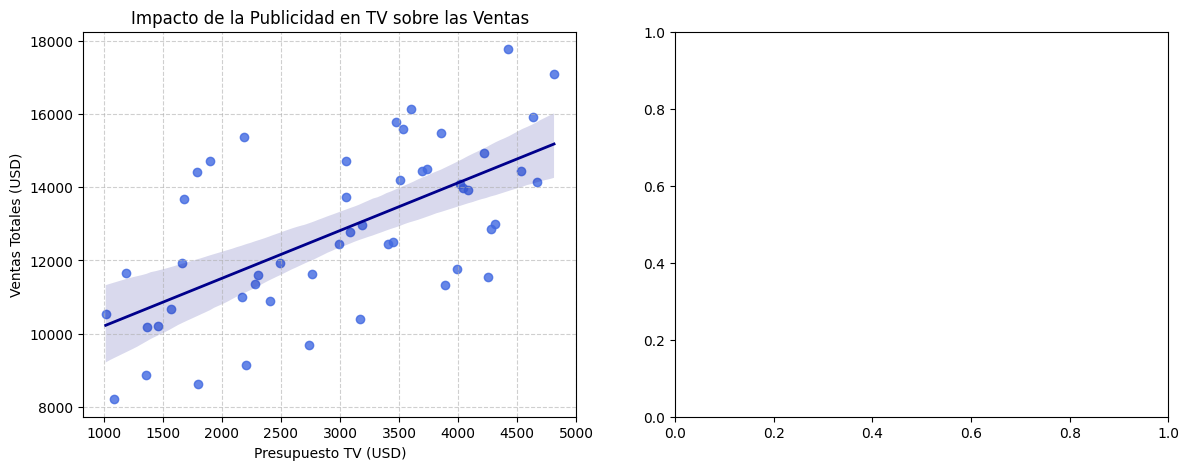

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

# 1. Simulación de datos (50 meses de campañas publicitarias)
np.random.seed(10)
meses = 50

gasto_tv = np.random.uniform(1000, 5000, meses)       # Inversión en TV entre $1000 y $5000
gasto_redes = np.random.uniform(500, 3000, meses)     # Inversión en Redes entre $500 y $3000

# Ventas base de 5000 + impacto de TV (x1.2) + impacto de Redes (x2.5) + ruido aleatorio
ventas = 5000 + (gasto_tv * 1.2) + (gasto_redes * 2.5) + np.random.normal(0, 300, meses)

# Crear el DataFrame de trabajo
df = pd.DataFrame({'TV': gasto_tv, 'Redes': gasto_redes, 'Ventas': ventas})

# 2. Entrenar el modelo de Regresión Lineal Múltiple
X = df[['TV', 'Redes']]
y = df['Ventas']
modelo = LinearRegression()
modelo.fit(X, y)

# ==========================================
# GRÁFICO 1: Análisis Individual (2D con Línea de Tendencia)
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico para televisión
sns.regplot(ax=axes[0], x='TV', y='Ventas', data=df, color='royalblue', marker='o',
            line_kws={'color': 'darkblue', 'linewidth': 2})
axes[0].set_title('Impacto de la Publicidad en TV sobre las Ventas')
axes[0].set_xlabel('Presupuesto TV (USD)')
axes[0].set_ylabel('Ventas Totales (USD)')
axes[0].grid(True, linestyle='--', alpha=0.6)

# Gráfico para redes sociales
sns.regplot(ax=axes[1], x='Redes', y='Ventas', data=df, color='seagreen', marker='s',
            line_kws={'color': 'darkgreen', 'linewidth': 2}, scatter_kws={'color': 'teal'})
axes[1].set_title('Impacto de las Redes Sociales sobre las Ventas')
axes[1].set_xlabel('Presupuesto Redes Sociales (USD)')
axes[1].set_ylabel('Ventas Totales (USD)')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# ==========================================
# GRÁFICO 2: Modelo Multidimensional (Plano de Regresión 3D)
# ==========================================
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Dibujar los puntos reales en el espacio 3D
ax.scatter(df['TV'], df['Redes'], df['Ventas'], color='crimson', marker='o', alpha=0.8, s=50, label='Datos Reales')

# Crear una malla (grid) para simular el plano predictivo continuo
x_surf = np.linspace(df['TV'].min(), df['TV'].max(), 20)
y_surf = np.linspace(df['Redes'].min(), df['Redes'].max(), 20)
x_surf, y_surf = np.meshgrid(x_surf, y_surf)

# Calcular las predicciones del plano usando los coeficientes obtenidos por el modelo
# Ecuación: Z = Intercepto + (Beta_1 * X) + (Beta_2 * Y)
z_surf = modelo.intercept_ + (modelo.coef_[0] * x_surf) + (modelo.coef_[1] * y_surf)

# Dibujar el plano de regresión estimado
ax.plot_surface(x_surf, y_surf, z_surf, cmap='viridis', alpha=0.4, rstride=1, cstride=1)

# Configuración de etiquetas y títulos del entorno 3D
ax.set_title('Plano de Regresión Lineal Múltiple (TV + Redes vs Ventas)', fontsize=14, pad=20)
ax.set_xlabel('Gasto TV (USD)', labelpad=10)
ax.set_ylabel('Gasto Redes (USD)', labelpad=10)
ax.set_zlabel('Ventas Totales (USD)', labelpad=10)
ax.legend()

# Ajustar ángulo de visión inicial para apreciar mejor la inclinación
ax.view_init(elev=20, azim=-60)

plt.show()